<h1 align="center"> CSE 242 Assignment 4, Spring 2025
Your name: Harshith Ravi Kopparam  Student ID: 2172472

## Instruction 

- Submit your assignments onto **canvas** by the due date. Upload a <code>zip</code> file containing:

    (1) The saved/latest <code>.ipynb</code> file, please **rename this file with your name included**.

    (2) Also save your file into a pdf version, if error appears, save an html version instead (easy to grade for written questions).
    
    **For assignment related questions, please reach TA or grader through Slack/Piazza/Email.**
    
- This is an **individual** assignment. All help from others (from the web, books other than text, or people other than the TA or instructor) must be clearly acknowledged. 

## Objective 

- **Task 1:** EM algorithm (Mathematical Derivation)
- **Task 2:** K-Means implementation (Coding)
- **Task 3:** Kernel Methods with Noisy Setting (Coding)


# Question 1. (EM algorithm, 20 pts) (the EM proof is for extra credit only)

Derive the E-step and M-step update equations of EM algorithm for estimating the Gaussian mixture model $p(X;\theta) = ∑_{k=1}^{K} \pi_k N(x; \mu_k, \sigma_k^2)$ where $\pi_k$ is the mixture weight with $\pi_k \ge 0$  and  $∑_{k=1}^{K} \pi_k = 1$, and $\mu_k$, $\sigma^2_k$ are the mean and variance of the gaussian distribution corresponding to cluster k. 

For the E-step, first prove that $z_{ik} = \color{blue}{P(z_i = k | X, \mu ,\sigma, \pi)} = \dfrac {\pi_k N(x_i; \mu_k, \sigma_k^2)}{∑_{k=1}^{K} \pi_k N(x_i; \mu_k, \sigma_k^2)}$. Then, for the M-step, show the derivation to compute the updates for $(\mu_k, \pi_k)$. Note that, you don't need to show the derivation for $\sigma_k$. For each derivation step, mention the concept applied (e.g. just 2-3 keywords, e.g. formula for expectation, independence of datapoints, (f+g)' = f' + g', etc ... ). 

**Hint:** For the M-step, you need to solve for $\mu_k^t = \underset{\mu_k}{argmax} \ E_{\color{blue}{p(Z | X, \mu^{(t-1)}, \sigma^{(t-1)}, \pi^{(t-1)})}}{[\log p(X, Z | \mu, \sigma, \pi)]}$ (and similarly for $\pi_k$) by applying the first order conditions for function optimization (take derivative and set it to zero). Note that the term $\color{blue}{p(Z|X,\mu^{(t-1)},\sigma^{(t-1)},\pi^{(t-1)})}$ is the one computed in the E-step, and uses fixed values for $\mu, \sigma, \pi$ from the previous iteration (t-1).







In [ ]:
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# Replace the figure name
# Image(filename='sample.png') 

# Question 2. (K-Means implementation, 20 pts)

#### **Question 2.1.** Implement K-means in Python from scratch. Complete following sub-functions `update_centroids` and `update_assignments`.



In [ ]:
def update_assignments(data, centroids):

  ########################
  #### YOUR CODE HERE ####

  ## you will get cluster# 
  ##assignments here #####
  ########################
  data_expanded = data[:, np.newaxis, :]
  distances = np.sqrt(((data_expanded - centroids) ** 2).sum(axis=2))
  assignments = np.argmin(distances, axis=1)
    
  return assignments

def update_centroids(data,centroids,assignments):

  ########################
  #### YOUR CODE HERE ####
  ########################
  new_centroids = np.zeros_like(centroids)
  for k in range(len(centroids)):
    mask = assignments == k
    if np.any(mask):
      new_centroids[k] = data[mask].mean(axis=0)
    else:
      new_centroids[k] = centroids[k]
  return new_centroids

def kmeans(data, centroids, max_iterations):    

    for j in range(max_iterations):
        # update cluter assignments
        assignments = update_assignments(data,centroids)    # WRITE CODE FOR update_assignments
        
        # update centroid locations
        centroids = update_centroids(data,centroids,assignments)  # WRITE CODE FOR update_centroids
        
    # final assignment update
    assignments = update_assignments(data,centroids)
    return centroids, assignments

#### **Question 2.2.** Run your code on following toy dataset for different k-values, where k = {2, 3, 4, 6, 10} and plot the cluster assignments for different k's as shown in following diagram.

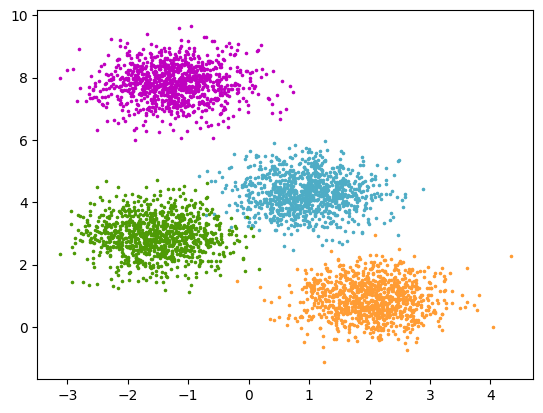

In [7]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate sample data
n_samples = 4000
n_components = 4

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=0.60, random_state=0
)

colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)


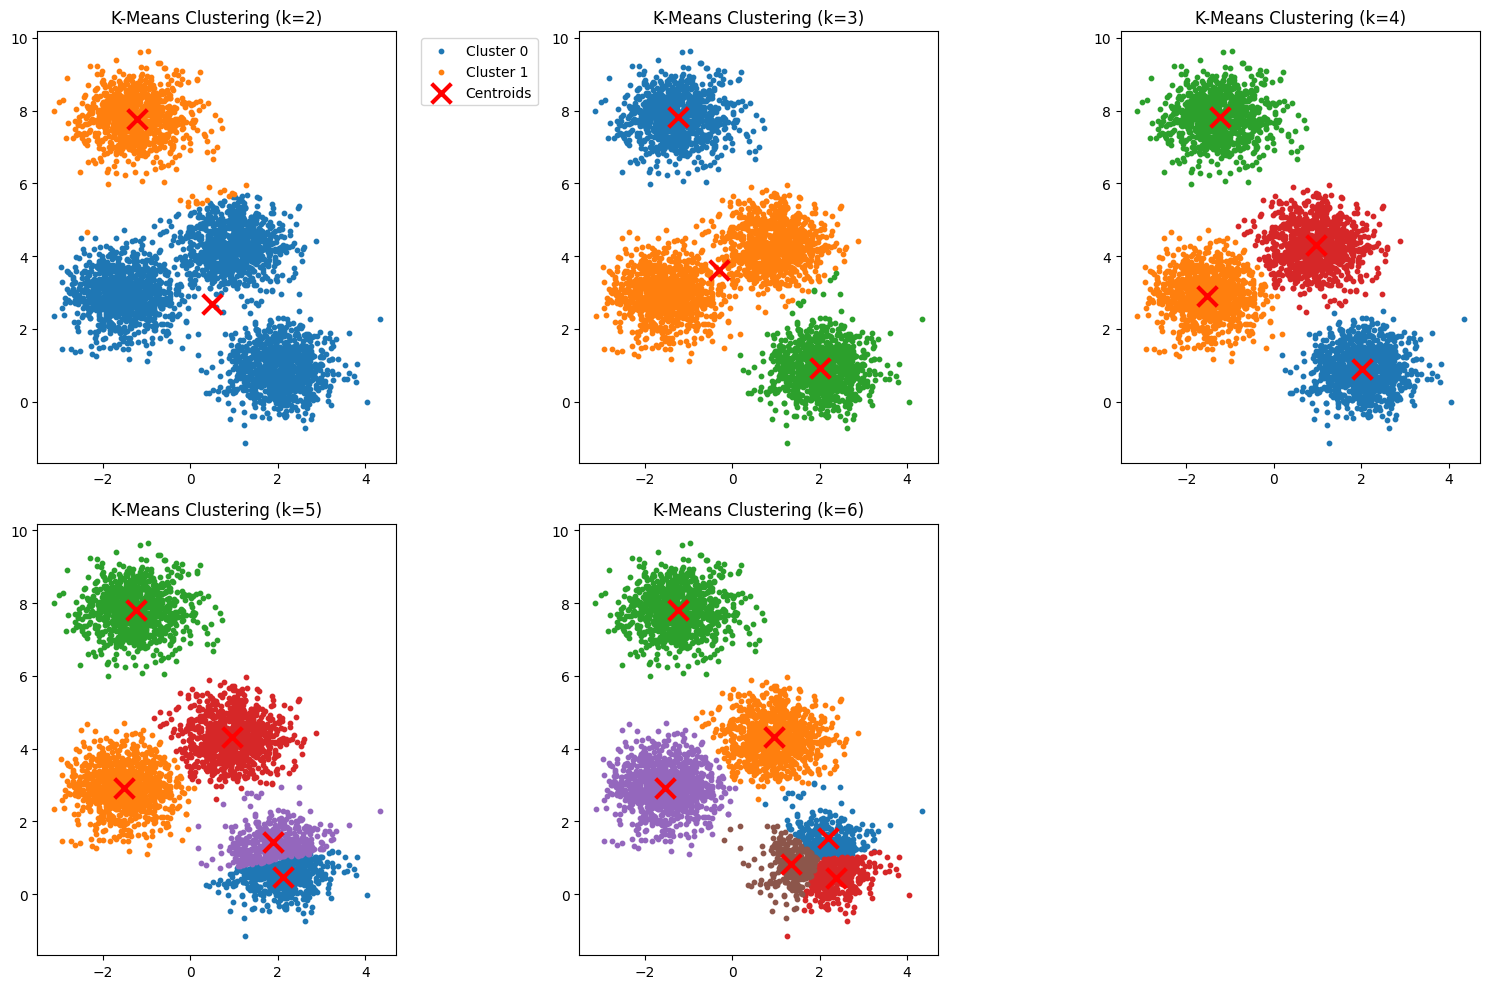

In [9]:

import numpy as np

def get_initial_clusters(k, X):
    random_indices = np.random.randint(0, X.shape[0], k)
    initial_centroids = X[random_indices]
    return initial_centroids

plt.figure(figsize=(15, 10))
k_values = [2, 3, 4, 5, 6]
for idx, k in enumerate(k_values, 1):
    initial_centroids = get_initial_clusters(k, X)
    final_centroids, assignments = kmeans(X, initial_centroids, max_iterations=100)
    plt.subplot(2, 3, idx)
    
    for i in range(k):
        mask = assignments == i
        plt.scatter(X[mask, 0], X[mask, 1], s=10, label=f'Cluster {i}' if idx == 1 else "")
    
    plt.scatter(final_centroids[:, 0], final_centroids[:, 1], 
                 c='red', marker='x', s=200, linewidth=3, label='Centroids')
    
    plt.title(f'K-Means Clustering (k={k})')
    if idx == 1:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Question 3. (Kernel Methods with Noisy Setting, 60 pts)

**SVM on synthetic dataset generated as follows:**

- Draw $1000\ (x_0, x_1)$ feature vectors from the 2-D Gaussian distribution with mean $\mu_+ = (1,1)$ and $\Sigma_+ = [1, 0; 0, 1]$ and label them as $+1$.

- Draw $1000\ (x_0, x_1)$ feature vectors from the 2-D Gaussian distribution with mean $\mu_- = (-1,-1)$ and $\Sigma_- = [3, 0; 0, 3]$ and label them as $-1$.
    
- This gives you a $2000$ example training set. Repeat the above to draw a test set the same way.

Use a SVM package ( scikit-learn svm.SVC class) to learn SVMs with a variety of parameter settings. 

In [15]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


X_train1 = np.random.multivariate_normal([1, 1], [[1, 0], [0, 1]], 1000)
X_train2 = np.random.multivariate_normal([-1, -1], [[3, 0], [0, 3]], 1000)

X_test1 = np.random.multivariate_normal([1, 1], [[1, 0], [0, 1]], 1000)
X_test2 = np.random.multivariate_normal([-1, -1], [[3, 0], [0, 3]], 1000)

Y_train1 = np.ones(1000)
Y_train2 = -1*np.ones(1000)

Y_test1 = np.ones(1000)
Y_test2 = -1*np.ones(1000)

X = np.concatenate((X_train1, X_train2), axis=0)
y = np.concatenate((Y_train1, Y_train2), axis=0)

X_train, y_train = shuffle(X, y, random_state=0)

X_test = np.concatenate((X_test1, X_test2), axis=0)
Y_test = np.concatenate((Y_test1, Y_test2), axis=0)

## (a -- 20 pts) 

- Use an RBF kernel with parameters $C=1$, $\gamma = 0.01$. 

- For each training data with +1 label, randomly flip their label to -1 with probability $\textbf{0.35}$.

- For each training data with -1 label, randomly flip their label to +1 with probability $\textbf{0.20}$.

- Train with the above noisy training examples.

- Random flipping introduces the randomness. You can repeat multiple times (e.g. 20) and then report the average accuracy on the testing dataset (clean) in the noise parameter setting. 



In [21]:
# Your code here
from sklearn.svm import SVC

def flip_labels(y, pos_flip_prob=0.35, neg_flip_prob=0.20):
    y_noisy = y.copy()
    
    # Flip positive labels
    pos_indices = np.where(y == 1)[0]
    flip_pos = np.random.rand(len(pos_indices)) < pos_flip_prob
    y_noisy[pos_indices[flip_pos]] = -1
    
    # Flip negative labels
    neg_indices = np.where(y == -1)[0]
    flip_neg = np.random.rand(len(neg_indices)) < neg_flip_prob
    y_noisy[neg_indices[flip_neg]] = 1
    
    return y_noisy

n_trials = 20
accuracies = []

for _ in range(n_trials):
    y_train_noisy = flip_labels(y_train)
    svm = SVC(kernel='rbf', C=1, gamma=0.01)
    svm.fit(X_train, y_train_noisy)
    y_pred = svm.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies.append(acc)

print(f"Average accuracy over {n_trials} trials: {np.mean(accuracies):.4f}")
print(f"Standard deviation: {np.std(accuracies):.4f}")

Average accuracy over 20 trials: 0.8241
Standard deviation: 0.0206


### using an RBF kernel SVM with parameters given above is: Average accuracy: 0.8241, pm: 0.0206

## (b -- 20 pts) Open question

- Try using **K-Nearst Neighbors** to correct wrong labels before training. 

- Then train the model with the newly processed training dataset. 

- Report the accuracy on the testing dataset in the noise parameter setting. Do you observe performance improvement?


In [ ]:
# Your code here
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def correct_labels_with_knn(X_train, y_train, k=5, noise_threshold=0.5):
    y_corrected = y_train.copy()
    

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    for i in range(len(y_train)):
        
        if y_train[i] != y_pred[i]:
            y_corrected[i] = y_pred[i] 
            
    return y_corrected


n_trials = 20
accuracies_with_knn = []
for _ in range(n_trials):
    y_train_corrected = correct_labels_with_knn(X_train, y_train)
    svm = SVC(kernel='rbf', C=1, gamma=0.01)
    svm.fit(X_train, y_train_corrected)
    y_pred = svm.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies_with_knn.append(acc)

# Print results
average_accuracy_with_knn = np.mean(accuracies_with_knn)
std_dev_with_knn = np.std(accuracies_with_knn)

print(f"Average accuracy with K-NN label correction: {average_accuracy_with_knn:.4f}")
print(f"Standard deviation: {std_dev_with_knn:.4f}")




Average accuracy with K-NN label correction: 0.8685
Standard deviation: 0.0000


### Average Accuracy with K-NN label correction is
- avg. label accuracy: 0.8685
- Standard Deviation: 0.0000

## (c -- 20 pts) Open question

- Try using **clustering (i.e., K-means, EM-clustering)** to correct wrong labels before training. 

- Then train the model with the newly processed training dataset. 

- Report the accuracy on the testing dataset in the noise parameter setting. Do you observe performance improvement?

In [26]:
# Your code here
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

def correct_labels_with_kmeans(X_train, y_train_noisy, n_clusters=2):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_train)
    
    y_corrected = y_train_noisy.copy()
    for cluster in range(n_clusters):
        cluster_mask = cluster_labels == cluster
        cluster_labels_count = np.bincount(
            (y_train_noisy[cluster_mask] == 1).astype(int))
        majority_label = 1 if cluster_labels_count[1] > cluster_labels_count[0] else -1
        y_corrected[cluster_mask] = majority_label
    
    return y_corrected

n_trials = 20
accuracies_with_kmeans = []

for _ in range(n_trials):
    y_train_noisy = flip_labels(y_train)
    y_train_corrected = correct_labels_with_kmeans(X_train, y_train_noisy)
    
    svm = SVC(kernel='rbf', C=1, gamma=0.01)
    svm.fit(X_train, y_train_corrected)
    
    y_pred = svm.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies_with_kmeans.append(acc)

print("\nResults with K-means label correction:")
print(f"Average accuracy: {np.mean(accuracies_with_kmeans):.4f}")
print(f"Standard deviation: {np.std(accuracies_with_kmeans):.4f}")

print("\nComparison of all methods:")
print("-" * 50)
print(f"Original SVM (noisy):     {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"KNN correction:           {np.mean(accuracies_with_knn):.4f} ± {np.std(accuracies_with_knn):.4f}")
print(f"K-means correction:       {np.mean(accuracies_with_kmeans):.4f} ± {np.std(accuracies_with_kmeans):.4f}")


Results with K-means label correction:
Average accuracy: 0.8410
Standard deviation: 0.0000

Comparison of all methods:
--------------------------------------------------
Original SVM (noisy):     0.8241 ± 0.0206
KNN correction:           0.8685 ± 0.0000
K-means correction:       0.8410 ± 0.0000
